# 5.1. 연산자란 무엇인가

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import hbar, m_e, e

L, N = 1e-9, 2000
dx = L / (N + 1)
x = np.linspace(0, L, N + 2)[1:-1]


def D1(N, dx):
    return (np.eye(N, k=1) - np.eye(N, k=-1)) / (2 * dx)


def D2(N, dx):
    return (-2 * np.eye(N) + np.eye(N, k=1) + np.eye(N, k=-1)) / dx**2


psi = np.sqrt(2 / L) * np.sin(np.pi * x / L)

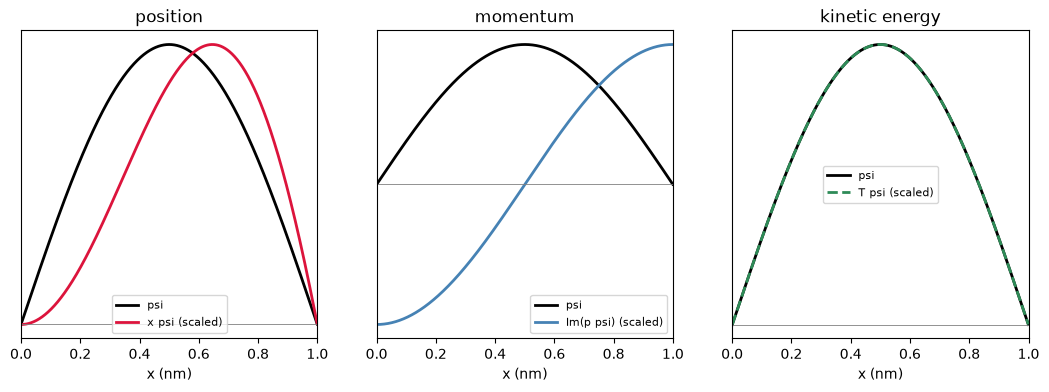

In [2]:
x_psi = x * psi
p_psi = -1j * hbar * (D1(N, dx) @ psi)
T_psi = -(hbar**2) / (2 * m_e) * (D2(N, dx) @ psi)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].plot(x * 1e9, psi / psi.max(), color="black", lw=2, label="psi")
axes[0].plot(
    x * 1e9, x_psi / x_psi.max(), color="crimson", lw=2, label="x psi (scaled)"
    )
axes[0].set_title("position")

axes[1].plot(x * 1e9, psi / psi.max(), color="black", lw=2, label="psi")
axes[1].plot(
    x * 1e9, p_psi.imag / np.abs(p_psi).max(), color="steelblue", lw=2, label="Im(p psi) (scaled)"
)
axes[1].set_title("momentum")

axes[2].plot(x * 1e9, psi / psi.max(), color="black", lw=2, label="psi")
axes[2].plot(
    x * 1e9, T_psi / T_psi.max(), color="seagreen", lw=2, ls="--", label="T psi (scaled)"
)
axes[2].set_title("kinetic energy")

for ax in axes:
    ax.axhline(0, color="gray", lw=0.6)
    ax.set_xlim(0, 1)
    ax.set_xlabel("x (nm)")
    ax.set_yticks([])
    ax.legend(fontsize=8)

plt.show()

In [3]:
ratio = (T_psi / psi) / e
print(f"T psi / psi = {ratio.mean():.6f} eV (표준편차 {ratio.std():.2e})")

E1 = np.pi**2 * hbar**2 / (2 * m_e * L**2) / e
print(f"해석해 E1    = {E1:.6f} eV")

T psi / psi = 0.376030 eV (표준편차 2.59e-09)
해석해 E1    = 0.376030 eV
